In [2]:
import pandas as pd
import os

In [3]:
provincias = {
    "Madrid":"../data/raw/Madrid",
    "Barcelona":"../data/raw/Barcelona",
    "Valencia":"../data/raw/Valencia"
}
dfs_por_provincia = {
    "Madrid": [],
    "Barcelona": [],
    "Valencia": []
}

for provincia, carpeta in provincias.items():
    for archivo in os.listdir(carpeta):
        if archivo.endswith(".csv"):
            ruta = os.path.join(carpeta, archivo)
            df = pd.read_csv(ruta, encoding="latin1", sep=";", decimal=",",thousands=".")
            df["Provincia"] = provincia
            dfs_por_provincia[provincia].append(df)


In [4]:
df_madrid = pd.concat(dfs_por_provincia["Madrid"])
df_barcelona = pd.concat(dfs_por_provincia["Barcelona"])
df_valencia = pd.concat(dfs_por_provincia["Valencia"])


In [5]:
df_barcelona.shape

(23649, 5)

In [6]:
df_barcelona = df_barcelona.copy()
df_barcelona["Geografía"].head(40)

#Valores unicos ordenados
sorted(df_barcelona["Geografía"].unique())
#Numero de filas con dos o mas espacios seguidos
df_barcelona["Geografía"].str.contains(r"\s{2,}").sum()
#Numero de filas que comienzan con un espacio
df_barcelona["Geografía"].str.startswith(" ").sum()
#Frecuencias de los valores
df_barcelona["Geografía"].str.lower().value_counts()
#Normaliza espacios y luego cuenta(ver si hay variantes del mismo muncipio)
df_barcelona["Geografía"].str.strip().str.lower().value_counts()
#Estadisticas de longitud de los str
df_barcelona["Geografía"].str.len().describe().T
#Cuenta valores nulos
df_barcelona["Geografía"].isna().sum()
#Cuenta strings vacios que no son nulos
df_barcelona["Geografía"].eq("").sum()
#str que empiezan con:
df_cp = df_barcelona[~df_barcelona["Geografía"].str.startswith("- Municipio de")]
#Detectamos simbolos extraños       
df_barcelona["Geografía"].str.contains(r"[-()_/]").sum() #->472
#Detectamos los valores con estos simbolos
df_barcelona[df_barcelona["Geografía"].str.contains(r"[-()_/]")]["Geografía"].unique()

df_barcelona


,Geografía,Tipología penal,Periodos:,Total,Provincia
0,- Municipio de Badalona,1.-Homicidios dolosos y asesinatos consumados,Enero-diciembre 2018,1,Barcelona
1,- Municipio de Badalona,2.-Homicidios dolosos y asesinatos en grado te...,Enero-diciembre 2018,8,Barcelona
2,- Municipio de Badalona,3.-Delitos graves y menos graves de lesiones y...,Enero-diciembre 2018,361,Barcelona
3,- Municipio de Badalona,4.-Secuestro,Enero-diciembre 2018,0,Barcelona
4,- Municipio de Badalona,5.-Delitos contra la libertad e indemnidad sexual,Enero-diciembre 2018,72,Barcelona
...,...,...,...,...,...
907,08219 Vilassar de Mar,11. Resto de criminalidad convencional,enero-diciembre 2024,252,Barcelona
908,08219 Vilassar de Mar,II. CIBERCRIMINALIDAD (infracciones penales co...,enero-diciembre 2024,186,Barcelona
909,08219 Vilassar de Mar,12.-Estafas informáticas,enero-diciembre 2024,172,Barcelona
910,08219 Vilassar de Mar,13.-Otros ciberdelitos,enero-diciembre 2024,14,Barcelona


In [7]:
df_barcelona["Periodos:"].value_counts()

Periodos:
enero-septiembre 2025    931
enero-junio 2025         931
enero-marzo 2025         931
enero-septiembre 2024    912
enero-marzo 2024         912
enero-diciembre 2023     912
enero-junio 2024         912
enero-diciembre 2024     912
Enero-junio 2023         893
Enero-marzo 2023         893
enero-septiembre 2023    893
Enero-diciembre 2022     893
Enero-marzo 2021         705
Enero-marzo 2022         705
Enero-septiembre 2022    705
Enero-junio 2022         705
Enero-diciembre 2021     705
Enero-junio 2021         705
Enero-septiembre 2021    705
Enero-diciembre 2018     465
Enero-septiembre 2020    465
Enero-junio 2019         465
Enero-marzo 2020         465
Enero-marzo 2019         465
Enero-diciembre 2019     465
Enero-septiembre 2019    465
Enero-diciembre 2020     465
Enero-junio 2020         465
Enero-diciembre 2017     434
Enero-junio 2018         434
Enero-marzo 2018         434
Enero-septiembre 2018    434
Enero-marzo 2017         420
Enero-junio 2017         420
Ener

In [8]:
df_barcelona.duplicated().sum()
df_valencia.duplicated().sum()
df_madrid.duplicated().sum()

np.int64(0)

In [9]:
def limpiar_geografia_general(df):
    """ Limpia la columna 'Geografía' eliminando códigos postales, 
    el prefijo '- Municipio de', espacios sobrantes y 
    corrige casos especiales detectados durante la auditoría de Madrid. 
    
    Parámetros: df (pd.DataFrame): DataFrame con la columna 'Geografía'. 
    Retorna: pd.Series: Columna 'Geografía' limpia. """
    #Seguridad
    df = df.copy()

    #Eliminar códigos postales (primeros 5 caracteres numéricos)
    df["Geografía"] = df["Geografía"].apply(lambda x: x[5:] if isinstance(x,str) and x[:5].isdigit() else x)
    
    #Eliminar el prefijo "- Municipio de"
    df["Geografía"] = df["Geografía"].apply(lambda x: x[14:] if isinstance(x,str) and x.lower().startswith("- municipio de") 
                                            else x[13:] if isinstance(x,str) and x.lower().startswith("-municipio de") 
                                            else x )
  
    #Eliminar espacios al inicio y final
    df["Geografía"] = df["Geografía"].str.strip()
    
    #Corrección puntual detectada en Madrid
    df["Geografía"] = df["Geografía"].replace("Rozas de Madrid (Las)","Las Rozas de Madrid")
    
    return df
df_limpieza_geografia = limpiar_geografia_general(df_barcelona)

"""
En este punto la columna 'Geografía' ya está limpiada a nivel general,
pero TODAVÍA NO hemos filtrado por municipios reales.

Esto es importante porque:
- En la provincia de Valencia aparecen municipios de Alicante y Castellón.
- También aparecen totales autonómicos y otras entidades no municipales.
- El objetivo es quedarnos SOLO con los municipios reales de la provincia de Valencia.

Ese filtrado se realiza en el siguiente paso del pipeline,
utilizando la lista de municipios válidos para cada provincia.
"""

df_limpieza_geografia 



,Geografía,Tipología penal,Periodos:,Total,Provincia
0,Badalona,1.-Homicidios dolosos y asesinatos consumados,Enero-diciembre 2018,1,Barcelona
1,Badalona,2.-Homicidios dolosos y asesinatos en grado te...,Enero-diciembre 2018,8,Barcelona
2,Badalona,3.-Delitos graves y menos graves de lesiones y...,Enero-diciembre 2018,361,Barcelona
3,Badalona,4.-Secuestro,Enero-diciembre 2018,0,Barcelona
4,Badalona,5.-Delitos contra la libertad e indemnidad sexual,Enero-diciembre 2018,72,Barcelona
...,...,...,...,...,...
907,Vilassar de Mar,11. Resto de criminalidad convencional,enero-diciembre 2024,252,Barcelona
908,Vilassar de Mar,II. CIBERCRIMINALIDAD (infracciones penales co...,enero-diciembre 2024,186,Barcelona
909,Vilassar de Mar,12.-Estafas informáticas,enero-diciembre 2024,172,Barcelona
910,Vilassar de Mar,13.-Otros ciberdelitos,enero-diciembre 2024,14,Barcelona


In [10]:
df_valencia["Geografía"].unique()

<StringArray>
[                                 'Provincia de ALICANTE/ALACANT',
                                     '- Municipio de Alcoy/Alcoi',
                                '- Municipio de Alicante/Alacant',
                                        '- Municipio de Benidorm',
                                       '- Municipio de Elche/Elx',
                                            '- Municipio de Elda',
                                        '- Municipio de Orihuela',
 '- Municipio de San Vicente del Raspeig/Sant Vicent del Raspeig',
                                      '- Municipio de Torrevieja',
                                'Provincia de CASTELLÓN/CASTELLÓ',
 ...
                                           '46220 Sagunto/Sagunt',
                                                    '46230 Silla',
                                                    '46235 Sueca',
                                                  '46244 Torrent',
                                           

In [11]:
df_barcelona["Geografía"].unique()

<StringArray>
[                    '- Municipio de Badalona',
           '- Municipio de Barberà del Vallès',
                    '- Municipio de Barcelona',
                '- Municipio de Castelldefels',
        '- Municipio de Cerdanyola del Vallès',
        '- Municipio de Cornellà de Llobregat',
       '- Municipio de Esplugues de Llobregat',
                         '- Municipio de Gavà',
                   '- Municipio de Granollers',
 '- Municipio de Hospitalet de Llobregat (L')',
 ...
              '08260 Santa Perpètua de Mogoda',
                                '08270 Sitges',
                              '08279 Terrassa',
                                   '08298 Vic',
                            '08301 Viladecans',
                '08305 Vilafranca del Penedès',
                  '08307 Vilanova i la Geltrú',
                       '08219 Vilassar de Mar',
             '-Municipio de Sant Just Desvern',
                               '08035 Calella']
Length: 128, dtype: s

In [12]:
"""
Limpieza semántica de la columna 'Tipología penal'.

En este paso eliminamos TODAS las categorías que NO representan delitos
municipales reales. Los datasets del Ministerio incluyen:
- Totales autonómicos (TOTAL INFRACCIONES PENALES)
- Totales provinciales (I., II., III.)
- Categorías europeas (EU-27, EU-15)
- Cibercrimen y estafas informáticas
- 'Resto de...' y otros agregados no desglosados

Estas filas NO deben aparecer en un análisis municipal, ya que mezclan
datos agregados de niveles superiores (provincia, comunidad, Europa).
"""
def limpiar_tipologia_penal(df):
    #Eliminamos tipología penal basura
    patron_basura = df["Tipología penal"].str.contains("TOTAL|Resto|I\.|II\.|III\.|EU|ciber|informátic",case=False, na=False)

    return df[~patron_basura].copy()
df_tipologia_penal_limpia = limpiar_tipologia_penal(df_limpieza_geografia)
"""
Una vez eliminadas las tipologías no válidas, el DataFrame contiene únicamente
delitos reales a nivel municipal. El siguiente paso del pipeline consiste en
normalizar los nombres de los municipios (València → Valencia, Puçol → Puzol, etc.)
para evitar duplicados y garantizar consistencia en el análisis.
"""
df_tipologia_penal_limpia

<>:17: SyntaxWarning: invalid escape sequence '\.'
<>:17: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_9232/3954635956.py:17: SyntaxWarning: invalid escape sequence '\.'
  patron_basura = df["Tipología penal"].str.contains("TOTAL|Resto|I\.|II\.|III\.|EU|ciber|informátic",case=False, na=False)


,Geografía,Tipología penal,Periodos:,Total,Provincia
0,Badalona,1.-Homicidios dolosos y asesinatos consumados,Enero-diciembre 2018,1,Barcelona
1,Badalona,2.-Homicidios dolosos y asesinatos en grado te...,Enero-diciembre 2018,8,Barcelona
2,Badalona,3.-Delitos graves y menos graves de lesiones y...,Enero-diciembre 2018,361,Barcelona
3,Badalona,4.-Secuestro,Enero-diciembre 2018,0,Barcelona
4,Badalona,5.-Delitos contra la libertad e indemnidad sexual,Enero-diciembre 2018,72,Barcelona
...,...,...,...,...,...
902,Vilassar de Mar,"7. Robos con fuerza en domicilios, establecimi...",enero-diciembre 2024,44,Barcelona
903,Vilassar de Mar,7.1.-Robos con fuerza en domicilios,enero-diciembre 2024,29,Barcelona
904,Vilassar de Mar,8. Hurtos,enero-diciembre 2024,113,Barcelona
905,Vilassar de Mar,9. Sustracciones de vehículos,enero-diciembre 2024,12,Barcelona


In [13]:
madrid = sorted(df_madrid["Geografía"].unique())
madrid[len(madrid)// 2:]

['-Municipio de Pozuelo de Alarcón',
 '-Municipio de Rivas-Vaciamadrid',
 '-Municipio de Rozas de Madrid (Las)',
 '-Municipio de San Fernando de Henares',
 '-Municipio de San Martín de la Vega',
 '-Municipio de San Sebastián de los Reyes',
 '-Municipio de Torrejón de Ardoz',
 '-Municipio de Torrelodones',
 '-Municipio de Tres Cantos',
 '-Municipio de Valdemoro',
 '-Municipio de Villaviciosa de Odón',
 '-Municipo de Villanueva de la Cañada',
 '28005 Alcalá de Henares',
 '28006 Alcobendas',
 '28007 Alcorcón',
 '28009 Algete',
 '28013 Aranjuez',
 '28014 Arganda del Rey',
 '28015 Arroyomolinos',
 '28022 Boadilla del Monte',
 '28040 Ciempozuelos',
 '28045 Colmenar Viejo',
 '28047 Collado Villalba',
 '28049 Coslada',
 '28058 Fuenlabrada',
 '28061 Galapagar',
 '28065 Getafe',
 '28073 Humanes de Madrid',
 '28074 Leganés',
 '28079 Madrid',
 '28080 Majadahonda',
 '28084 Mejorada del Campo',
 '28092 Móstoles',
 '28096 Navalcarnero',
 '28104 Paracuellos de Jarama',
 '28106 Parla',
 '28113 Pinto',


In [14]:
'''Diccionario de normalización específico para la provincia de Valencia. 

Convierte variantes lingüísticas (valenciano/catalán) y nombres inconsistentes 
a su forma estándar en castellano para evitar duplicados en el análisis.'''

mapa_municipios_valencia = {
    "Gandia": "Gandía",
    "Paterna": "Paterna",
    "Sagunto/Sagunt": "Sagunto",
    "Torrent": "Torrent",
    "Valencia": "Valencia",
    "València": "Valencia",
    "Alzira": "Alcira",
    "Aldaia": "Aldaya",
    "Burjassot": "Burjasot",
    "Manises": "Manises",
    "Mislata": "Mislata",
    "Ontinyent": "Onteniente",
    "Algemesí": "Algemesí",
    "Bétera": "Bétera",
    "Carcaixent": "Carcagente",
    "Catarroja": "Catarroja",
    "Cullera": "Cullera",
    "Llíria": "Liria",
    "Moncada": "Moncada",
    "Oliva": "Oliva",
    "Paiporta": "Paiporta",
    "Picassent": "Picassent",
    "Pobla de Vallbona (la)": "La Pobla de Vallbona",
    "Puçol": "Puzol",
    "Quart de Poblet": "Quart de Poblet",
    "Requena": "Requena",
    "Riba-roja de Túria": "Ribarroja del Turia",
    "Sueca": "Sueca",
    "Xàtiva": "Játiva",
    "Xirivella": "Xirivella",
    "Silla": "Silla",
    "Alfafar": "Alfafar",
    "Alboraya": "Alboraya",
    "Alaquàs": "Alaquás"
}
mapa_municipios_barcelona = {
    "Badalona": "Badalona",
    "Barberà del Vallès": "Barberà del Vallès",
    "Barcelona": "Barcelona",
    "Calella": "Calella",
    "Castellar del Vallès": "Castellar del Vallès",
    "Castelldefels": "Castelldefels",
    "Cerdanyola del Vallès": "Cerdanyola del Vallès",
    "Cornellà de Llobregat": "Cornellà de Llobregat",
    "Esparreguera": "Esparreguera",
    "Esplugues de Llobregat": "Esplugues de Llobregat",
    "Gavà": "Gavà",
    "Granollers": "Granollers",
    "Hospitalet de Llobregat (L')": "L'Hospitalet de Llobregat",
    "Igualada": "Igualada",
    "Les Franqueses del Vallès": "Les Franqueses del Vallès",
    "Manlleu": "Manlleu",
    "Manresa": "Manresa",
    "Martorell": "Martorell",
    "Masnou (El)": "El Masnou",
    "Mataró": "Mataró",
    "Molins de Rei": "Molins de Rei",
    "Mollet del Vallès": "Mollet del Vallès",
    "Montcada i Reixac": "Montcada i Reixac",
    "Olesa de Montserrat": "Olesa de Montserrat",
    "Pineda de Mar": "Pineda de Mar",
    "Prat de Llobregat (El)": "El Prat de Llobregat",
    "Premià de Mar": "Premià de Mar",
    "Ripollet": "Ripollet",
    "Rubí": "Rubí",
    "Sabadell": "Sabadell",
    "Sant Adrià de Besòs": "Sant Adrià de Besòs",
    "Sant Andreu de la Barca": "Sant Andreu de la Barca",
    "Sant Boi de Llobregat": "Sant Boi de Llobregat",
    "Sant Cugat del Vallès": "Sant Cugat del Vallès",
    "Sant Feliu de Llobregat": "Sant Feliu de Llobregat",
    "Sant Joan Despí": "Sant Joan Despí",
    "Sant Just Desvern": "Sant Just Desvern",
    "Sant Pere de Ribes": "Sant Pere de Ribes",
    "Sant Quirze del Vallès": "Sant Quirze del Vallès",
    "Sant Vicenç dels Horts": "Sant Vicenç dels Horts",
    "Santa Coloma de Gramenet": "Santa Coloma de Gramenet",
    "Santa Perpètua de Mogoda": "Santa Perpètua de Mogoda",
    "Sitges": "Sitges",
    "Terrassa": "Terrassa",
    "Vic": "Vic",
    "Viladecans": "Viladecans",
    "Vilafranca del Penedès": "Vilafranca del Penedès",
    "Vilanova i la Geltrú": "Vilanova i la Geltrú",
    "Vilassar de Mar": "Vilassar de Mar"
}

def normalizar_nombres_municipios(df, municipios):
    """ Normaliza los nombres de los municipios según un diccionario específico de cada provincia. 
    
    Esta función: 
    - Unifica variantes lingüísticas (ej. 'València' → 'Valencia'). 
    - Elimina duplicados causados por diferencias ortográficas. 
    - Garantiza consistencia en la columna 'Geografía' para análisis posteriores. 
    
    Parámetros: 
    df : DataFrame ya filtrado y con tipologías limpias.
    mapa : Diccionario de normalización para la provincia correspondiente. 
    
    NOTA: Esta función es ESPECÍFICA por provincia. 
    Para Barcelona, Madrid u otras provincias será necesario crear sus propios diccionarios de normalización y reutilizar esta misma función. """
    df["Geografía"] = df["Geografía"].replace(municipios)

    return df
df_municipios_normalizados = normalizar_nombres_municipios(df_tipologia_penal_limpia,mapa_municipios_barcelona)
df_municipios_normalizados




,Geografía,Tipología penal,Periodos:,Total,Provincia
0,Badalona,1.-Homicidios dolosos y asesinatos consumados,Enero-diciembre 2018,1,Barcelona
1,Badalona,2.-Homicidios dolosos y asesinatos en grado te...,Enero-diciembre 2018,8,Barcelona
2,Badalona,3.-Delitos graves y menos graves de lesiones y...,Enero-diciembre 2018,361,Barcelona
3,Badalona,4.-Secuestro,Enero-diciembre 2018,0,Barcelona
4,Badalona,5.-Delitos contra la libertad e indemnidad sexual,Enero-diciembre 2018,72,Barcelona
...,...,...,...,...,...
902,Vilassar de Mar,"7. Robos con fuerza en domicilios, establecimi...",enero-diciembre 2024,44,Barcelona
903,Vilassar de Mar,7.1.-Robos con fuerza en domicilios,enero-diciembre 2024,29,Barcelona
904,Vilassar de Mar,8. Hurtos,enero-diciembre 2024,113,Barcelona
905,Vilassar de Mar,9. Sustracciones de vehículos,enero-diciembre 2024,12,Barcelona


In [15]:
df_municipios_normalizados["Tipología penal"].value_counts()


Tipología penal
5.1.-Agresión sexual con penetración                                          1397
7.1.-Robos con fuerza en domicilios                                           1397
1.-Homicidios dolosos y asesinatos consumados                                  822
2.-Homicidios dolosos y asesinatos en grado tentativa                          822
3.-Delitos graves y menos graves de lesiones y riña tumultuaria                822
4.-Secuestro                                                                   822
5.-Delitos contra la libertad e indemnidad sexual                              822
6.-Robos con violencia e intimidación                                          822
7.- Robos con fuerza en domicilios, establecimientos y otras instalaciones     822
8.-Hurtos                                                                      822
9.-Sustracciones de vehículos                                                  822
10.-Tráfico de drogas                                                  

In [16]:
def normalizar_texto_tipologia_penal(df):
    df = df.copy()
    df["Tipología penal"] = (df["Tipología penal"]
                             .str.strip()
                             .str.lower()
                             .str.replace(r"^[^a-zA-Z]+", "", regex=True) #elimina todo lo que no sea letra al inicio
                             .str.replace(r"\(.*?\)", "", regex=True) #elimina paréntesis
                             .str.replace(r"\s+", " ", regex=True) #normaliza espacios
                             .str.strip()
                             )
    df["Tipología penal"] = df["Tipología penal"].str.title()
    return df

df_tipologia_penal_normalizado = normalizar_texto_tipologia_penal(df_municipios_normalizados)
df_tipologia_penal_normalizado

,Geografía,Tipología penal,Periodos:,Total,Provincia
0,Badalona,Homicidios Dolosos Y Asesinatos Consumados,Enero-diciembre 2018,1,Barcelona
1,Badalona,Homicidios Dolosos Y Asesinatos En Grado Tenta...,Enero-diciembre 2018,8,Barcelona
2,Badalona,Delitos Graves Y Menos Graves De Lesiones Y Ri...,Enero-diciembre 2018,361,Barcelona
3,Badalona,Secuestro,Enero-diciembre 2018,0,Barcelona
4,Badalona,Delitos Contra La Libertad E Indemnidad Sexual,Enero-diciembre 2018,72,Barcelona
...,...,...,...,...,...
902,Vilassar de Mar,"Robos Con Fuerza En Domicilios, Establecimient...",enero-diciembre 2024,44,Barcelona
903,Vilassar de Mar,Robos Con Fuerza En Domicilios,enero-diciembre 2024,29,Barcelona
904,Vilassar de Mar,Hurtos,enero-diciembre 2024,113,Barcelona
905,Vilassar de Mar,Sustracciones De Vehículos,enero-diciembre 2024,12,Barcelona


In [17]:
df_tipologia_penal_normalizado["Tipología penal"].unique()


<StringArray>
[                            'Homicidios Dolosos Y Asesinatos Consumados',
                     'Homicidios Dolosos Y Asesinatos En Grado Tentativa',
           'Delitos Graves Y Menos Graves De Lesiones Y Riña Tumultuaria',
                                                              'Secuestro',
                         'Delitos Contra La Libertad E Indemnidad Sexual',
                                        'Agresión Sexual Con Penetración',
                                     'Robos Con Violencia E Intimidación',
 'Robos Con Fuerza En Domicilios, Establecimientos Y Otras Instalaciones',
                                         'Robos Con Fuerza En Domicilios',
                                                                 'Hurtos',
                                             'Sustracciones De Vehículos',
                                                      'Tráfico De Drogas',
                                                                  'Daños',
           

In [18]:
def generalizacion_tipologia_penal(df):
    mapa_delitos = {
    "Homicidios Dolosos Y Asesinatos Consumados": "Homicidios",
    "Homicidios Dolosos Y Asesinatos En Grado Tentativa": "Homicidios",
    "Delitos Graves Y Menos Graves De Lesiones Y Riña Tumultuaria": "Lesiones",
    "Delitos Contra La Libertad Sexual": "Delitos Sexuales",
    "Delitos Contra La Libertad E Indemnidad Sexual": "Delitos Sexuales",
    "Agresión Sexual Con Penetración": "Delitos Sexuales",
    "Secuestro": "Secuestro",
    "Robos Con Fuerza En Domicilios": "Robos Con Fuerza",
    "Robos Con Fuerza En Domicilios, Establecimientos Y Otras Instalaciones": "Robos Con Fuerza",
    "Robos Con Violencia E Intimidación": "Robos Con Violencia",
    "Sustracciones De Vehículos": "Sustraccion De Vehiculos",
    "Hurtos": "Hurtos",
    "Tráfico De Drogas": "Trafico De Drogas",
    "Daños": "Daños"
}
    df["Delitos"] = df["Tipología penal"].map(mapa_delitos)
    return df

df_generalizacion_delitos = generalizacion_tipologia_penal(df_tipologia_penal_normalizado)
df_generalizacion_delitos


,Geografía,Tipología penal,Periodos:,Total,Provincia,Delitos
0,Badalona,Homicidios Dolosos Y Asesinatos Consumados,Enero-diciembre 2018,1,Barcelona,Homicidios
1,Badalona,Homicidios Dolosos Y Asesinatos En Grado Tenta...,Enero-diciembre 2018,8,Barcelona,Homicidios
2,Badalona,Delitos Graves Y Menos Graves De Lesiones Y Ri...,Enero-diciembre 2018,361,Barcelona,Lesiones
3,Badalona,Secuestro,Enero-diciembre 2018,0,Barcelona,Secuestro
4,Badalona,Delitos Contra La Libertad E Indemnidad Sexual,Enero-diciembre 2018,72,Barcelona,Delitos Sexuales
...,...,...,...,...,...,...
902,Vilassar de Mar,"Robos Con Fuerza En Domicilios, Establecimient...",enero-diciembre 2024,44,Barcelona,Robos Con Fuerza
903,Vilassar de Mar,Robos Con Fuerza En Domicilios,enero-diciembre 2024,29,Barcelona,Robos Con Fuerza
904,Vilassar de Mar,Hurtos,enero-diciembre 2024,113,Barcelona,Hurtos
905,Vilassar de Mar,Sustracciones De Vehículos,enero-diciembre 2024,12,Barcelona,Sustraccion De Vehiculos


In [19]:
sorted(df_generalizacion_delitos["Periodos:"].unique())

df_generalizacion_delitos["Periodos:"].str.startswith(" ").sum()

df_generalizacion_delitos["Periodos:"].str.strip().str.lower().value_counts()

df_generalizacion_delitos["Periodos:"].str.len().describe().T

df_generalizacion_delitos["Periodos:"].isna().sum()

df_generalizacion_delitos["Periodos:"].eq("").sum()


#Que valores de la columna "Periodos:" no cumplen el formato correcto:
#Que empiecen con una palabra
#Guion obligatorio
#Otra palabra
#Espacio
#Un año de 4 digitos
df_generalizacion_delitos[
    ~df_generalizacion_delitos["Periodos:"].str.match(r"^[A-Za-zÁÉÍÓÚáéíóúñÑ]+-[A-Za-zÁÉÍÓÚáéíóúñÑ]+ \d{4}$")
]["Periodos:"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [20]:
def normalizacion_año_trimestres(df):
    #Extraccion de texto para normalizacion
    df["Periodos"] = df["Periodos:"].str.extract(r"^([A-Za-zÁÉÍÓÚáéíóúñÑ\-]+)")
    df["Periodos"] = df["Periodos"].str.title()

    #Extraccion del año
    df["Año"] = df["Periodos:"].str.extract(r"(\d{4})$")

    #Asignar trimestres de acuerdo a los periodos
    mapa_trimestres = {
        "Enero-Marzo":"T1",
        "Enero-Junio":"T2",
        "Enero-Septiembre":"T3",
        "Enero-Diciembre":"T4"
    }

    df["Trimestre"] = df["Periodos"].map(mapa_trimestres)

    #Ordenamos Trimestres para poder obtener el valor real de los delitos por cada trimestre
    orden_trimestres = ["T1","T2","T3","T4"]
    df["Trimestre"] = pd.Categorical(df["Trimestre"],
                                     categories=orden_trimestres,
                                     ordered=True)
    #Ordenamos df
    df = df.sort_values(["Geografía", "Delitos", "Año", "Trimestre","Provincia"])

    return df

df_periodos = normalizacion_año_trimestres(df_generalizacion_delitos)

#Los años se extrajeorn bien?
df_periodos[df_periodos["Año"].isna()]["Periodos:"].unique()
#Los trimestres se asignaron bien?
df_periodos["Trimestre"].value_counts(dropna=False)
df_periodos


,Geografía,Tipología penal,Periodos:,Total,Provincia,Delitos,Periodos,Año,Trimestre
6,Badalona,Daños,Enero-marzo 2016,277,Barcelona,Daños,Enero-Marzo,2016,T1
6,Badalona,Daños,Enero-junio 2016,596,Barcelona,Daños,Enero-Junio,2016,T2
6,Badalona,Daños,Enero-Septiembre 2016,887,Barcelona,Daños,Enero-Septiembre,2016,T3
6,Badalona,Daños,Enero-Diciembre 2016,1170,Barcelona,Daños,Enero-Diciembre,2016,T4
4,Badalona,Delitos Contra La Libertad E Indemnidad Sexual,Enero-marzo 2017,11,Barcelona,Delitos Sexuales,Enero-Marzo,2017,T1
...,...,...,...,...,...,...,...,...,...
906,Vilassar de Mar,Tráfico De Drogas,enero-septiembre 2024,2,Barcelona,Trafico De Drogas,Enero-Septiembre,2024,T3
906,Vilassar de Mar,Tráfico De Drogas,enero-diciembre 2024,2,Barcelona,Trafico De Drogas,Enero-Diciembre,2024,T4
925,Vilassar de Mar,Tráfico De Drogas,enero-marzo 2025,0,Barcelona,Trafico De Drogas,Enero-Marzo,2025,T1
925,Vilassar de Mar,Tráfico De Drogas,enero-junio 2025,0,Barcelona,Trafico De Drogas,Enero-Junio,2025,T2


In [21]:
df_periodos["Periodos"].unique()
df_periodos[df_periodos["Delitos"].isna()]["Tipología penal"].unique()


<StringArray>
[]
Length: 0, dtype: str

### Informacion
-Agrupamos y dentro de cada grupo sumamos la columna "Total". Por que?:
-Antes teniamos un mismo delito con diferentes nombres, como los categorizamos en delitos mas "generales" tenemos que sumarlos para obtener el valor real de esa categoria delictiva general

In [22]:
def agregar_duplicados_tipologias(df):
    df = df.groupby(["Geografía", "Delitos", "Año", "Trimestre", "Provincia"], as_index=False )["Total"].sum()
    return df
df_suma_tipologias = agregar_duplicados_tipologias(df_periodos)
df_suma_tipologias

,Geografía,Delitos,Año,Trimestre,Provincia,Total
0,Badalona,Daños,2016,T1,Barcelona,277
1,Badalona,Daños,2016,T2,Barcelona,596
2,Badalona,Daños,2016,T3,Barcelona,887
3,Badalona,Daños,2016,T4,Barcelona,1170
4,Badalona,Delitos Sexuales,2017,T1,Barcelona,12
...,...,...,...,...,...,...
12720,Vilassar de Mar,Trafico De Drogas,2024,T3,Barcelona,2
12721,Vilassar de Mar,Trafico De Drogas,2024,T4,Barcelona,2
12722,Vilassar de Mar,Trafico De Drogas,2025,T1,Barcelona,0
12723,Vilassar de Mar,Trafico De Drogas,2025,T2,Barcelona,0


### Informacion 
-Es importante entender que para realizar el siguiente calculo tuvimos que, previamente, ordenar el df(en la funcion normalizacion_año_trimestres) para garantizar el orden de los trimestres y poder obtener su valor real restando los acumulados entre ellos (Total) con diff()

-En este punto detecté un acumulado falso:

Un trimestre posterior no puede ser menor que el anterior porque los datos del Ministerio son acumulados.
Cada trimestre suma lo que ya había antes:

T1 = enero–marzo
T2 = enero–junio
T3 = enero–septiembre
T4 = enero–diciembre

Por eso el acumulado siempre sube o se mantiene, nunca baja.
Si vemos algo como:

T3 = 11
T4 = 0

eso significa que el dato de T4 no existe y aparece como 0 por defecto.
Cuando pasa esto, corregimos ese acumulado usando el valor anterior para que la serie tenga sentido y no salgan valores negativos al calcular los trimestres reales.

In [23]:
def calcular_trimestres_reales(df):

    #Obtenemos el acumulado de cada agrupacion
    total_agrupacion = df.groupby(["Geografía","Delitos","Año"])["Total"]

    #Desplaza los valores una fila hacia abajo dentro de cada grupo:
    #En cada fila, 'acumulado_anterior' contiene el acumulado del trimestre anterior
    acumulado_anterior = total_agrupacion.shift()

    # Marcamos como inválidas las filas donde el acumulado baja respecto al trimestre anterior
    df["invalido"] = df["Total"] < acumulado_anterior

    #Detectamos acumulados FALSOS:
    #Si el acumulado actual es menor que el anterior, ese valor no puede ser real
    mask = df["Total"] < acumulado_anterior #Mascara para detectar acumulados que bajan

    #Corregimos los acumulados inválidos: 
    #En las filas donde el acumulado baja, sustituimos por el acumulado anterior
    df.loc[mask, "Total"] = acumulado_anterior 

    #Calculo del valor real de cada trimestre
    #Dentro de cada grupo restamos el acumulado anterior (diff)
    #Rellenamos el NaN del T1 con su propio acumulado(fillna)    
    df["Valor trimestral"] = df.groupby(["Geografía", "Delitos", "Año"])["Total"].diff().fillna(df["Total"])
    
    #Eliminamos columna INVALIDO que ya no necesitamos
    df = df.drop(columns="invalido")
    return df

df_trimestres_reales = calcular_trimestres_reales(df_suma_tipologias)
df_trimestres_reales


,Geografía,Delitos,Año,Trimestre,Provincia,Total,Valor trimestral
0,Badalona,Daños,2016,T1,Barcelona,277,277.0
1,Badalona,Daños,2016,T2,Barcelona,596,319.0
2,Badalona,Daños,2016,T3,Barcelona,887,291.0
3,Badalona,Daños,2016,T4,Barcelona,1170,283.0
4,Badalona,Delitos Sexuales,2017,T1,Barcelona,12,12.0
...,...,...,...,...,...,...,...
12720,Vilassar de Mar,Trafico De Drogas,2024,T3,Barcelona,2,0.0
12721,Vilassar de Mar,Trafico De Drogas,2024,T4,Barcelona,2,0.0
12722,Vilassar de Mar,Trafico De Drogas,2025,T1,Barcelona,0,0.0
12723,Vilassar de Mar,Trafico De Drogas,2025,T2,Barcelona,0,0.0


In [24]:
df["Total"].head()
df["Total"].dtype

dtype('int64')

In [25]:
def pipeline_provincia(df, mapa_normalizacion):
    df = limpiar_geografia_general(df)
    df = limpiar_tipologia_penal(df)
    df = normalizar_nombres_municipios(df, mapa_normalizacion)
    df = normalizar_texto_tipologia_penal(df)
    df = generalizacion_tipologia_penal(df)
    df = normalizacion_año_trimestres(df)
    df = agregar_duplicados_tipologias(df)
    df = calcular_trimestres_reales(df)
    return df

df_valencia_limpio = pipeline_provincia(df_valencia, mapa_municipios_valencia)
df_barcelona_limpio = pipeline_provincia(df_barcelona, mapa_municipios_barcelona)
df_madrid_limpio = pipeline_provincia(df_madrid, {}) 
df_barcelona_limpio


,Geografía,Delitos,Año,Trimestre,Provincia,Total,Valor trimestral
0,Badalona,Daños,2016,T1,Barcelona,277,277.0
1,Badalona,Daños,2016,T2,Barcelona,596,319.0
2,Badalona,Daños,2016,T3,Barcelona,887,291.0
3,Badalona,Daños,2016,T4,Barcelona,1170,283.0
4,Badalona,Delitos Sexuales,2017,T1,Barcelona,12,12.0
...,...,...,...,...,...,...,...
12720,Vilassar de Mar,Trafico De Drogas,2024,T3,Barcelona,2,0.0
12721,Vilassar de Mar,Trafico De Drogas,2024,T4,Barcelona,2,0.0
12722,Vilassar de Mar,Trafico De Drogas,2025,T1,Barcelona,0,0.0
12723,Vilassar de Mar,Trafico De Drogas,2025,T2,Barcelona,0,0.0


In [26]:
df_final = pd.concat([df_valencia_limpio, df_barcelona_limpio, df_madrid_limpio], ignore_index=True)
df_final.to_csv("../data/processed/df_final.csv", index=False)


### Falta agregar la poblacion
-Podré detectar cambios de criminalidad por estaciones(incierno,verano,etc)
-Aplicar Series temporales sobre cada cluster para obtener predicciones sobre delitos por trimestres, tasas por municipio, evoluciona anual, cambios estructurales, incluso municipios que cambian de cluster con el tiempo, zonas que aumentan criminalidad, etc

In [27]:
df_final

,Geografía,Delitos,Año,Trimestre,Provincia,Total,Valor trimestral
0,Alaquás,Delitos Sexuales,2021,T2,Valencia,2,2.0
1,Alaquás,Delitos Sexuales,2021,T3,Valencia,2,0.0
2,Alaquás,Delitos Sexuales,2021,T4,Valencia,4,2.0
3,Alaquás,Delitos Sexuales,2022,T2,Valencia,2,2.0
4,Alaquás,Delitos Sexuales,2022,T3,Valencia,5,3.0
...,...,...,...,...,...,...,...
34057,Villaviciosa de Odón,Trafico De Drogas,2024,T3,Madrid,3,2.0
34058,Villaviciosa de Odón,Trafico De Drogas,2024,T4,Madrid,4,1.0
34059,Villaviciosa de Odón,Trafico De Drogas,2025,T1,Madrid,0,0.0
34060,Villaviciosa de Odón,Trafico De Drogas,2025,T2,Madrid,1,1.0


In [28]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 34062 entries, 0 to 34061
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Geografía         34062 non-null  str     
 1   Delitos           34062 non-null  str     
 2   Año               34062 non-null  str     
 3   Trimestre         34062 non-null  category
 4   Provincia         34062 non-null  str     
 5   Total             34062 non-null  int64   
 6   Valor trimestral  34062 non-null  float64 
dtypes: category(1), float64(1), int64(1), str(4)
memory usage: 1.6 MB


In [29]:
df_final['Año'] = df_final['Año'].astype(int)

In [30]:
df_final

,Geografía,Delitos,Año,Trimestre,Provincia,Total,Valor trimestral
0,Alaquás,Delitos Sexuales,2021,T2,Valencia,2,2.0
1,Alaquás,Delitos Sexuales,2021,T3,Valencia,2,0.0
2,Alaquás,Delitos Sexuales,2021,T4,Valencia,4,2.0
3,Alaquás,Delitos Sexuales,2022,T2,Valencia,2,2.0
4,Alaquás,Delitos Sexuales,2022,T3,Valencia,5,3.0
...,...,...,...,...,...,...,...
34057,Villaviciosa de Odón,Trafico De Drogas,2024,T3,Madrid,3,2.0
34058,Villaviciosa de Odón,Trafico De Drogas,2024,T4,Madrid,4,1.0
34059,Villaviciosa de Odón,Trafico De Drogas,2025,T1,Madrid,0,0.0
34060,Villaviciosa de Odón,Trafico De Drogas,2025,T2,Madrid,1,1.0


In [31]:
df_madrid_p = pd.read_csv('../data/raw/Poblacion/poblacion-madrid.csv', sep=';', encoding='latin1')
df_barcelona_p = pd.read_csv('../data/raw/Poblacion/poblacion-Barcelona.csv', sep=';', encoding='latin1')
df_valencia_p = pd.read_csv('../data/raw/Poblacion/poblacion-valencia.csv', sep=';', encoding='latin1')


In [32]:
df_poblacion_total = pd.concat([df_madrid_p, df_barcelona_p, df_valencia_p])
df_poblacion_total

,Sexo,Municipios,Periodo,Total
0,Total,"28001 Acebeda, La",2025,70
1,Total,"28001 Acebeda, La",2024,68
2,Total,"28001 Acebeda, La",2023,67
3,Total,"28001 Acebeda, La",2022,62
4,Total,"28001 Acebeda, La",2021,55
...,...,...,...,...
2665,Total,46263 Zarra,2020,346
2666,Total,46263 Zarra,2019,359
2667,Total,46263 Zarra,2018,365
2668,Total,46263 Zarra,2017,381


In [33]:

df_poblacion_total['Municipios'] = df_poblacion_total['Municipios'].str.replace(r'^\d+\s+', '', regex=True)
df_poblacion_total

,Sexo,Municipios,Periodo,Total
0,Total,"Acebeda, La",2025,70
1,Total,"Acebeda, La",2024,68
2,Total,"Acebeda, La",2023,67
3,Total,"Acebeda, La",2022,62
4,Total,"Acebeda, La",2021,55
...,...,...,...,...
2665,Total,Zarra,2020,346
2666,Total,Zarra,2019,359
2667,Total,Zarra,2018,365
2668,Total,Zarra,2017,381


In [34]:
df_final

,Geografía,Delitos,Año,Trimestre,Provincia,Total,Valor trimestral
0,Alaquás,Delitos Sexuales,2021,T2,Valencia,2,2.0
1,Alaquás,Delitos Sexuales,2021,T3,Valencia,2,0.0
2,Alaquás,Delitos Sexuales,2021,T4,Valencia,4,2.0
3,Alaquás,Delitos Sexuales,2022,T2,Valencia,2,2.0
4,Alaquás,Delitos Sexuales,2022,T3,Valencia,5,3.0
...,...,...,...,...,...,...,...
34057,Villaviciosa de Odón,Trafico De Drogas,2024,T3,Madrid,3,2.0
34058,Villaviciosa de Odón,Trafico De Drogas,2024,T4,Madrid,4,1.0
34059,Villaviciosa de Odón,Trafico De Drogas,2025,T1,Madrid,0,0.0
34060,Villaviciosa de Odón,Trafico De Drogas,2025,T2,Madrid,1,1.0


In [35]:
'''Diccionario de normalización específico para la provincia de Valencia. 

Convierte variantes lingüísticas (valenciano/catalán) y nombres inconsistentes 
a su forma estándar en castellano para evitar duplicados en el análisis.'''

mapa_municipios_valencia = {
    "Gandia": "Gandía",
    "Paterna": "Paterna",
    "Sagunto/Sagunt": "Sagunto",
    "Torrent": "Torrent",
    "Valencia": "Valencia",
    "València": "Valencia",
    "Alzira": "Alcira",
    "Aldaia": "Aldaya",
    "Burjassot": "Burjasot",
    "Manises": "Manises",
    "Mislata": "Mislata",
    "Ontinyent": "Onteniente",
    "Algemesí": "Algemesí",
    "Bétera": "Bétera",
    "Carcaixent": "Carcagente",
    "Catarroja": "Catarroja",
    "Cullera": "Cullera",
    "Llíria": "Liria",
    "Moncada": "Moncada",
    "Oliva": "Oliva",
    "Paiporta": "Paiporta",
    "Picassent": "Picassent",
    "Pobla de Vallbona (la)": "La Pobla de Vallbona",
    "Puçol": "Puzol",
    "Quart de Poblet": "Quart de Poblet",
    "Requena": "Requena",
    "Riba-roja de Túria": "Ribarroja del Turia",
    "Sueca": "Sueca",
    "Xàtiva": "Játiva",
    "Xirivella": "Xirivella",
    "Silla": "Silla",
    "Alfafar": "Alfafar",
    "Alboraya": "Alboraya",
    "Alaquàs": "Alaquás"
}
mapa_municipios_barcelona = {
    "Badalona": "Badalona",
    "Barberà del Vallès": "Barberà del Vallès",
    "Barcelona": "Barcelona",
    "Calella": "Calella",
    "Castellar del Vallès": "Castellar del Vallès",
    "Castelldefels": "Castelldefels",
    "Cerdanyola del Vallès": "Cerdanyola del Vallès",
    "Cornellà de Llobregat": "Cornellà de Llobregat",
    "Esparreguera": "Esparreguera",
    "Esplugues de Llobregat": "Esplugues de Llobregat",
    "Gavà": "Gavà",
    "Granollers": "Granollers",
    "Hospitalet de Llobregat (L')": "L'Hospitalet de Llobregat",
    "Igualada": "Igualada",
    "Les Franqueses del Vallès": "Les Franqueses del Vallès",
    "Manlleu": "Manlleu",
    "Manresa": "Manresa",
    "Martorell": "Martorell",
    "Masnou (El)": "El Masnou",
    "Mataró": "Mataró",
    "Molins de Rei": "Molins de Rei",
    "Mollet del Vallès": "Mollet del Vallès",
    "Montcada i Reixac": "Montcada i Reixac",
    "Olesa de Montserrat": "Olesa de Montserrat",
    "Pineda de Mar": "Pineda de Mar",
    "Prat de Llobregat (El)": "El Prat de Llobregat",
    "Premià de Mar": "Premià de Mar",
    "Ripollet": "Ripollet",
    "Rubí": "Rubí",
    "Sabadell": "Sabadell",
    "Sant Adrià de Besòs": "Sant Adrià de Besòs",
    "Sant Andreu de la Barca": "Sant Andreu de la Barca",
    "Sant Boi de Llobregat": "Sant Boi de Llobregat",
    "Sant Cugat del Vallès": "Sant Cugat del Vallès",
    "Sant Feliu de Llobregat": "Sant Feliu de Llobregat",
    "Sant Joan Despí": "Sant Joan Despí",
    "Sant Just Desvern": "Sant Just Desvern",
    "Sant Pere de Ribes": "Sant Pere de Ribes",
    "Sant Quirze del Vallès": "Sant Quirze del Vallès",
    "Sant Vicenç dels Horts": "Sant Vicenç dels Horts",
    "Santa Coloma de Gramenet": "Santa Coloma de Gramenet",
    "Santa Perpètua de Mogoda": "Santa Perpètua de Mogoda",
    "Sitges": "Sitges",
    "Terrassa": "Terrassa",
    "Vic": "Vic",
    "Viladecans": "Viladecans",
    "Vilafranca del Penedès": "Vilafranca del Penedès",
    "Vilanova i la Geltrú": "Vilanova i la Geltrú",
    "Vilassar de Mar": "Vilassar de Mar"
}

def normalizar_nombres_municipios(df, municipios):
    df["Municipios"] = df["Municipios"].replace(municipios)
    return df

df_municipios_normalizados_p = normalizar_nombres_municipios(df_poblacion_total,mapa_municipios_valencia)

In [36]:
df_unido = df_final.merge(df_municipios_normalizados_p, 
                          left_on=['Geografía', 'Año'], 
                          right_on=['Municipios', 'Periodo'], 
                          how='left')
df_unido

,Geografía,Delitos,Año,Trimestre,Provincia,Total_x,Valor trimestral,Sexo,Municipios,Periodo,Total_y
0,Alaquás,Delitos Sexuales,2021,T2,Valencia,2,2.0,Total,Alaquás,2021.0,29.649
1,Alaquás,Delitos Sexuales,2021,T3,Valencia,2,0.0,Total,Alaquás,2021.0,29.649
2,Alaquás,Delitos Sexuales,2021,T4,Valencia,4,2.0,Total,Alaquás,2021.0,29.649
3,Alaquás,Delitos Sexuales,2022,T2,Valencia,2,2.0,Total,Alaquás,2022.0,29.537
4,Alaquás,Delitos Sexuales,2022,T3,Valencia,5,3.0,Total,Alaquás,2022.0,29.537
...,...,...,...,...,...,...,...,...,...,...,...
34703,Villaviciosa de Odón,Trafico De Drogas,2024,T3,Madrid,3,2.0,Total,Villaviciosa de Odón,2024.0,29.273
34704,Villaviciosa de Odón,Trafico De Drogas,2024,T4,Madrid,4,1.0,Total,Villaviciosa de Odón,2024.0,29.273
34705,Villaviciosa de Odón,Trafico De Drogas,2025,T1,Madrid,0,0.0,Total,Villaviciosa de Odón,2025.0,30.127
34706,Villaviciosa de Odón,Trafico De Drogas,2025,T2,Madrid,1,1.0,Total,Villaviciosa de Odón,2025.0,30.127


Se realiza un merge (unión) entre el DataFrame de delitos (df_final) y el de población (df_municipios_normalizados_p) para consolidar toda la información en una única tabla.

In [37]:
# Cambiar el nombre de las columnas

df_merge = df_unido.rename(columns={'Total_x': 'Total_Delitos',
                                    'Total_y': 'Poblacion_Total',})
df_merge

,Geografía,Delitos,Año,Trimestre,Provincia,Total_Delitos,Valor trimestral,Sexo,Municipios,Periodo,Poblacion_Total
0,Alaquás,Delitos Sexuales,2021,T2,Valencia,2,2.0,Total,Alaquás,2021.0,29.649
1,Alaquás,Delitos Sexuales,2021,T3,Valencia,2,0.0,Total,Alaquás,2021.0,29.649
2,Alaquás,Delitos Sexuales,2021,T4,Valencia,4,2.0,Total,Alaquás,2021.0,29.649
3,Alaquás,Delitos Sexuales,2022,T2,Valencia,2,2.0,Total,Alaquás,2022.0,29.537
4,Alaquás,Delitos Sexuales,2022,T3,Valencia,5,3.0,Total,Alaquás,2022.0,29.537
...,...,...,...,...,...,...,...,...,...,...,...
34703,Villaviciosa de Odón,Trafico De Drogas,2024,T3,Madrid,3,2.0,Total,Villaviciosa de Odón,2024.0,29.273
34704,Villaviciosa de Odón,Trafico De Drogas,2024,T4,Madrid,4,1.0,Total,Villaviciosa de Odón,2024.0,29.273
34705,Villaviciosa de Odón,Trafico De Drogas,2025,T1,Madrid,0,0.0,Total,Villaviciosa de Odón,2025.0,30.127
34706,Villaviciosa de Odón,Trafico De Drogas,2025,T2,Madrid,1,1.0,Total,Villaviciosa de Odón,2025.0,30.127


In [38]:
df_merge = df_merge.drop(columns=['Periodo', 'Municipios'])

#### Eliminación de columnas redundantes
Se eliminan `Periodo` y `Municiopios` debido a que duplica la información ya existente en la columna `Año` y `Geografía`.

In [39]:
df_merge

,Geografía,Delitos,Año,Trimestre,Provincia,Total_Delitos,Valor trimestral,Sexo,Poblacion_Total
0,Alaquás,Delitos Sexuales,2021,T2,Valencia,2,2.0,Total,29.649
1,Alaquás,Delitos Sexuales,2021,T3,Valencia,2,0.0,Total,29.649
2,Alaquás,Delitos Sexuales,2021,T4,Valencia,4,2.0,Total,29.649
3,Alaquás,Delitos Sexuales,2022,T2,Valencia,2,2.0,Total,29.537
4,Alaquás,Delitos Sexuales,2022,T3,Valencia,5,3.0,Total,29.537
...,...,...,...,...,...,...,...,...,...
34703,Villaviciosa de Odón,Trafico De Drogas,2024,T3,Madrid,3,2.0,Total,29.273
34704,Villaviciosa de Odón,Trafico De Drogas,2024,T4,Madrid,4,1.0,Total,29.273
34705,Villaviciosa de Odón,Trafico De Drogas,2025,T1,Madrid,0,0.0,Total,30.127
34706,Villaviciosa de Odón,Trafico De Drogas,2025,T2,Madrid,1,1.0,Total,30.127


# Análisis Multivariante

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [41]:
df_merge['Poblacion_Total'] = df_merge['Poblacion_Total'].astype(str).str.replace('.', '').astype(float)

### Análisis de Correlación (Heatmap)
¿Existe relación directa entre el tamaño de la población y el número de delitos, o influye más el trimestre del año?

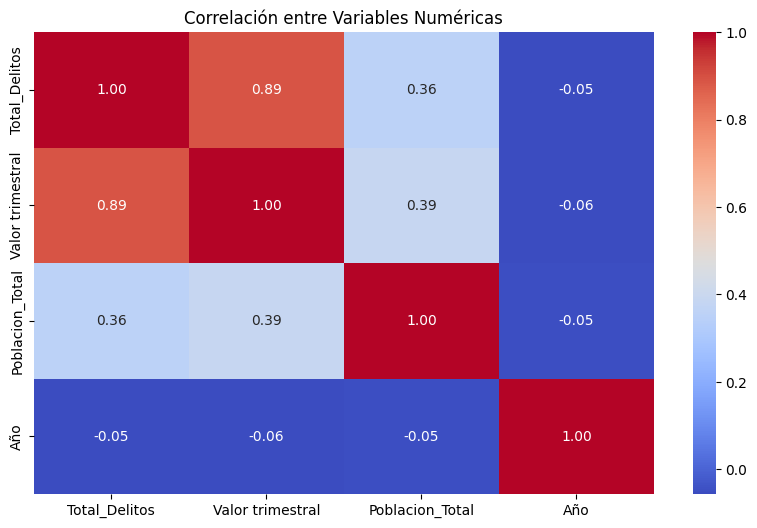

In [42]:
# Matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_merge[['Total_Delitos', 'Valor trimestral', 'Poblacion_Total', 'Año']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Numéricas')
plt.show()

Existe una relación positiva muy alta entre `Total_Delitos` y `Valor trimestral`. Esto indica que ambas variables se mueven casi en la misma dirección; si una sube, la otra también lo hace de forma proporcional.


La `Poblacion_Total` tiene una influencia positiva pero limitada sobre el `Total_Delitos` y el `Valor trimestral`. Aunque ciudades más grandes tienden a tener más delitos, el tamaño de la población no es el único factor determinante.

La variable `Año` prácticamente no tiene relación lineal con las demás. Esto sugiere que el paso del tiempo, por sí solo, no ha provocado un aumento o descenso sistemático y lineal en la criminalidad o en la población en este dataset.

### Análisis por Categorías (Delitos vs. Geografía)
Aquí es donde vemos qué tipo de delitos predominan según la provincia o municipio.

Boxplot Multivariante: Comparar la distribución de Total_Delitos por Provincia y Delitos.

Normalización: Es vital calcular una Tasa de Criminalidad, ya que Madrid siempre tendrá más delitos que Alaquás simplemente por volumen de personas.

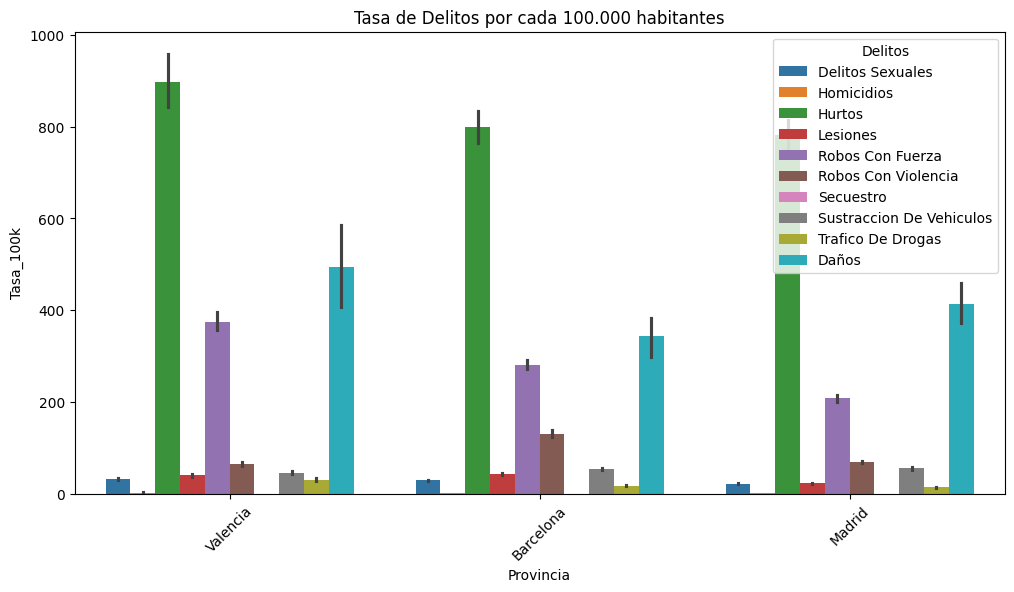

In [45]:
# Crear ratio para una comparación justa
df_merge['Tasa_100k'] = (df_merge['Total_Delitos'] / df_merge['Poblacion_Total']) * 100000

# Visualización de Tasa por Provincia y Tipo de Delito
plt.figure(figsize=(12, 6))
sns.barplot(data=df_merge, x='Provincia', y='Tasa_100k', hue='Delitos')
plt.title('Tasa de Delitos por cada 100.000 habitantes')
plt.xticks(rotation=45)
plt.show()

### Análisis de Series Temporales (Tendencias)

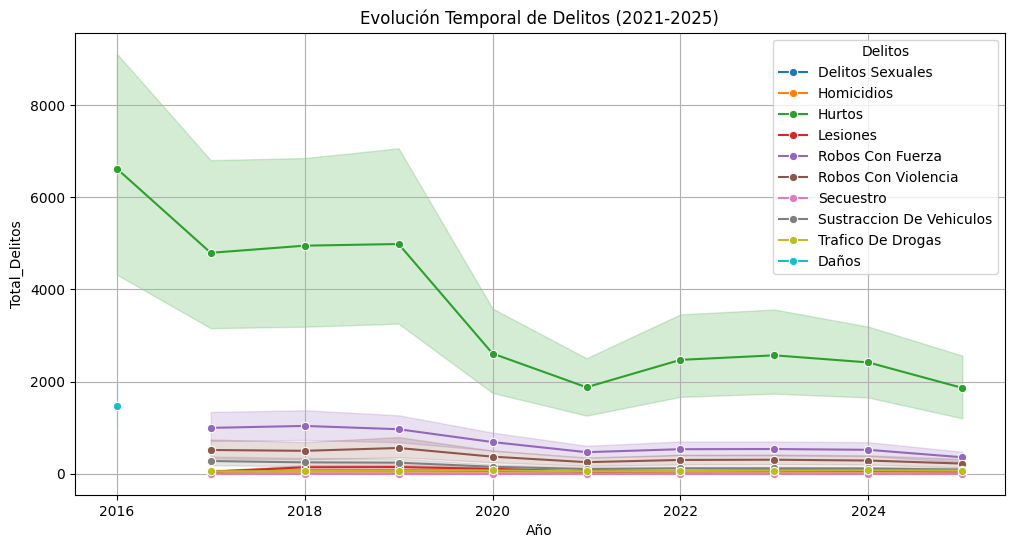

In [46]:
# Evolución temporal por tipo de delito
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_merge, x='Año', y='Total_Delitos', hue='Delitos', marker='o')
plt.title('Evolución Temporal de Delitos (2021-2025)')
plt.grid(True)
plt.show()